# Customer Segmentation and Lifetime Value Prediction

This notebook covers the complete workflow including data loading, cleaning, feature engineering, clustering, regression modeling, and statistical validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import f_oneway

In [2]:
demographics = pd.read_csv("../data/raw/demographics.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")

In [3]:
demographics.head()

,customer_id,age,income,signup_date
0,1,56,104740.0,2024-08-15
1,2,69,NaN,2024-12-14
2,3,46,96617.0,2024-09-23
3,4,32,124841.0,2023-02-28
4,5,60,46896.0,2023-05-08


In [4]:
transactions.head()

,transaction_id,customer_id,transaction_date,amount,category
0,1,440,2025-06-06,58.550629,Clothing
1,2,164,2025-08-19,140.473729,Home
2,3,301,2025-02-08,110.689465,Clothing
3,4,407,2024-08-01,13.613417,Home
4,5,303,2025-11-15,85.154367,Electronics


In [5]:
demographics.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer_id  500 non-null    int64  
 1   age          500 non-null    int64  
 2   income       475 non-null    float64
 3   signup_date  500 non-null    str    
dtypes: float64(1), int64(2), str(1)
memory usage: 20.6 KB


In [6]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5000 non-null   int64  
 1   customer_id       5000 non-null   int64  
 2   transaction_date  5000 non-null   str    
 3   amount            5000 non-null   float64
 4   category          5000 non-null   str    
dtypes: float64(1), int64(2), str(2)
memory usage: 282.0 KB


In [7]:
demographics.describe()

,customer_id,age,income
count,500.000000,500.000000,475.000000
mean,250.500000,44.732000,88105.229474
std,144.481833,15.239707,34086.167322
min,1.000000,18.000000,30384.000000
25%,125.750000,32.000000,57597.500000
50%,250.500000,45.000000,86800.000000
75%,375.250000,57.000000,118566.000000
max,500.000000,70.000000,149803.000000


In [8]:
transactions.describe()

,transaction_id,customer_id,amount
count,5000.000000,5000.00000,5000.000000
mean,2500.500000,253.05700,159.681412
std,1443.520003,144.17767,433.867554
min,1.000000,1.00000,-691.199979
25%,1250.750000,128.00000,35.551335
50%,2500.500000,254.00000,84.679057
75%,3750.250000,380.00000,172.039537
max,5000.000000,500.00000,8791.657247


In [9]:
demographics.isnull().sum()

customer_id     0
age             0
income         25
signup_date     0
dtype: int64

In [10]:
transactions.isnull().sum()

transaction_id      0
customer_id         0
transaction_date    0
amount              0
category            0
dtype: int64

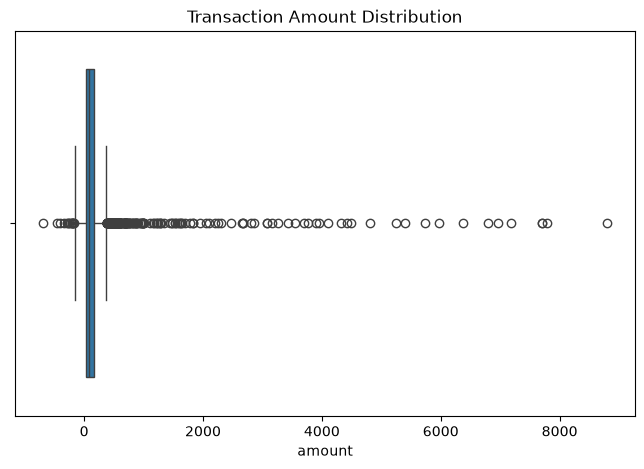

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=transactions["amount"])
plt.title("Transaction Amount Distribution")
plt.show()

## Initial Observations

- The demographics dataset contains missing income values.
- The transactions dataset contains extreme outliers and some negative values.
- These issues must be cleaned before feature engineering and clustering.

## Data Cleaning

This section handles missing income values and transaction outliers to improve data quality before feature engineering.

In [12]:
demographics["age_group"] = pd.cut(
    demographics["age"],
    bins=[17, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

In [13]:
demographics["income"] = demographics.groupby("age_group")["income"].transform(
    lambda x: x.fillna(x.median())
)

In [14]:
demographics.isnull().sum()

customer_id    0
age            0
income         0
signup_date    0
age_group      0
dtype: int64

Missing income values were filled using the median income of the corresponding age group. This preserves realistic income patterns across age ranges.

In [15]:
transactions = transactions[transactions["amount"] > 0]

In [16]:
transactions["amount"].min()

np.float64(0.0222254935450874)

Negative transaction amounts were removed because they represent returns and would distort monetary analysis.

In [17]:
q1 = transactions["amount"].quantile(0.25)
q3 = transactions["amount"].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

In [18]:
transactions["amount"] = transactions["amount"].clip(
    lower=lower_limit,
    upper=upper_limit
)

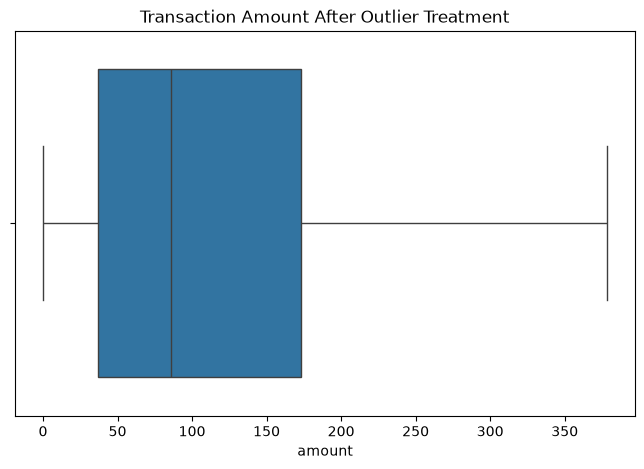

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=transactions["amount"])
plt.title("Transaction Amount After Outlier Treatment")
plt.show()

In [20]:
demographics.describe()

,customer_id,age,income
count,500.000000,500.000000,500.000000
mean,250.500000,44.732000,88095.978000
std,144.481833,15.239707,33225.708989
min,1.000000,18.000000,30384.000000
25%,125.750000,32.000000,59328.500000
50%,250.500000,45.000000,87799.000000
75%,375.250000,57.000000,117017.250000
max,500.000000,70.000000,149803.000000


In [21]:
transactions.describe()

,transaction_id,customer_id,amount
count,4950.000000,4950.000000,4950.000000
mean,2500.577576,252.906263,119.555303
std,1442.841934,144.044213,106.529139
min,1.000000,1.000000,0.022225
25%,1251.250000,128.000000,36.626601
50%,2501.500000,253.000000,85.789647
75%,3747.750000,380.000000,173.234446
max,5000.000000,500.000000,378.146212


## RFM Feature Engineering

RFM analysis transforms raw transaction history into customer-level behavior metrics.

In [22]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [23]:
reference_date = transactions["transaction_date"].max()
reference_date

Timestamp('2026-06-01 00:00:00')

In [24]:
rfm = transactions.groupby("customer_id").agg({
    "transaction_date": lambda x: (reference_date - x.max()).days,
    "transaction_id": "count",
    "amount": "sum"
}).reset_index()

In [25]:
rfm.columns = ["customer_id", "Recency", "Frequency", "Monetary"]

In [26]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,1,8,8,987.903952
1,2,143,9,1366.939256
2,3,45,13,1423.398043
3,4,28,6,701.655780
4,5,21,13,1592.736404


In [27]:
rfm["customer_id"].nunique()

500

In [28]:
abt = pd.merge(demographics, rfm, on="customer_id", how="inner")

In [29]:
abt = abt.drop(columns=["signup_date", "age_group"])

In [30]:
abt.head()

,customer_id,age,income,Recency,Frequency,Monetary
0,1,56,104740.0,8,8,987.903952
1,2,69,90403.0,143,9,1366.939256
2,3,46,96617.0,45,13,1423.398043
3,4,32,124841.0,28,6,701.655780
4,5,60,46896.0,21,13,1592.736404


In [31]:
abt.shape

(500, 6)

In [32]:
abt.to_csv("../data/processed/abt.csv", index=False)

In [33]:
pd.read_csv("../data/processed/abt.csv").head()

,customer_id,age,income,Recency,Frequency,Monetary
0,1,56,104740.0,8,8,987.903952
1,2,69,90403.0,143,9,1366.939256
2,3,46,96617.0,45,13,1423.398043
3,4,32,124841.0,28,6,701.655780
4,5,60,46896.0,21,13,1592.736404


The analytical base table combines customer demographics with behavioral RFM metrics. This creates one unified dataset for clustering and predictive modeling.

## Customer Segmentation using K-Means

This section applies clustering to discover natural customer groups based on RFM and demographic features.

In [34]:
features = abt[["Recency", "Frequency", "Monetary", "age", "income"]]

In [35]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [36]:
scaled_features[:5]

array([[-0.92155567, -0.59369203, -0.38579402,  0.74012478,  0.50143974],
       [ 0.64394094, -0.28122254,  0.36144346,  1.59401387,  0.06950439],
       [-0.49249364,  0.96865541,  0.4727474 ,  0.08328703,  0.25671554],
       [-0.68963025, -1.218631  , -0.95010917, -0.83628583,  1.10702896],
       [-0.77080415,  0.96865541,  0.8065843 ,  1.00285989, -1.24124484]])

In [37]:
wcss = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_features)

    wcss.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(scaled_features, labels)
    )

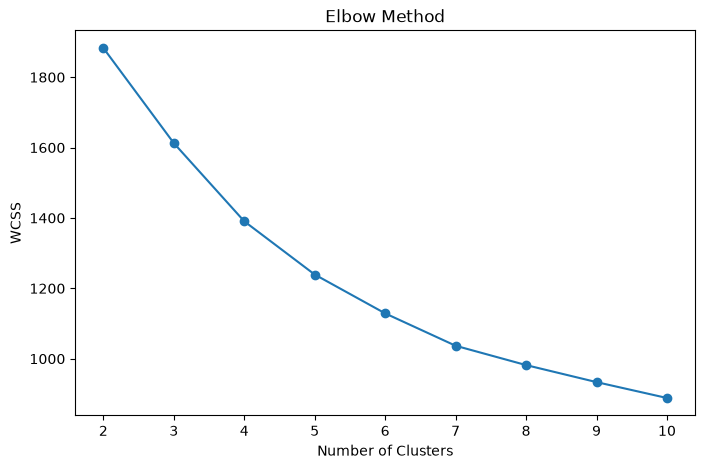

In [38]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

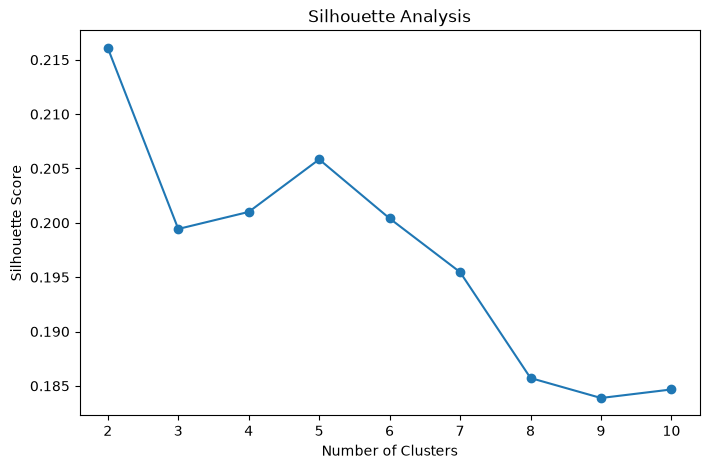

In [39]:
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Based on the elbow method and silhouette analysis, K=4 was selected because it provides a good balance between compact clusters and business interpretability.

In [40]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
abt["Cluster"] = kmeans.fit_predict(scaled_features)

In [41]:
abt.head()

,customer_id,age,income,Recency,Frequency,Monetary,Cluster
0,1,56,104740.0,8,8,987.903952,2
1,2,69,90403.0,143,9,1366.939256,2
2,3,46,96617.0,45,13,1423.398043,0
3,4,32,124841.0,28,6,701.655780,3
4,5,60,46896.0,21,13,1592.736404,0


In [42]:
cluster_profiles = abt.groupby("Cluster").mean()
cluster_profiles

,customer_id,age,income,Recency,Frequency,Monetary
Cluster,,,,,,
0,259.659420,45.833333,87689.673913,53.072464,13.579710,1776.610847
1,270.797297,47.824324,76850.702703,246.756757,7.391892,860.129483
2,243.440252,55.679245,100016.616352,60.484277,8.276730,935.437355
3,237.759690,28.286822,80288.527132,66.155039,9.403101,1040.638232


In [43]:
abt["Cluster"].value_counts()

Cluster
2    159
0    138
3    129
1     74
Name: count, dtype: int64

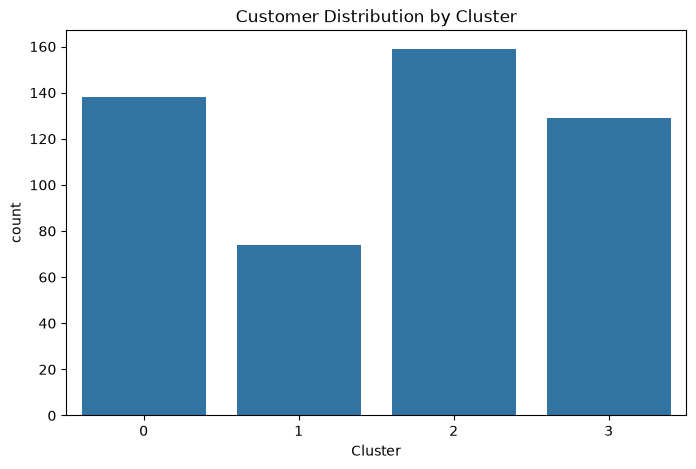

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(x="Cluster", data=abt)
plt.title("Customer Distribution by Cluster")
plt.show()

In [45]:
abt.to_csv("../data/processed/abt.csv", index=False)

## Customer Personas

Cluster 0 → High-Value Loyalists  
Cluster 1 → New Potential Buyers  
Cluster 2 → At-Risk Customers  
Cluster 3 → Frequent Low-Spenders

## Lifetime Value Prediction

This section builds a regression model to predict customer lifetime value using behavioral and demographic features.

In [46]:
abt["Average_Order_Value"] = abt["Monetary"] / abt["Frequency"]
abt["LTV_proxy"] = abt["Frequency"] * abt["Average_Order_Value"]

In [47]:
abt[["Frequency", "Average_Order_Value", "LTV_proxy"]].head()

,Frequency,Average_Order_Value,LTV_proxy
0,8,123.487994,987.903952
1,9,151.882140,1366.939256
2,13,109.492157,1423.398043
3,6,116.942630,701.655780
4,13,122.518185,1592.736404


In [48]:
X = abt[["Recency", "Frequency", "Monetary", "age", "income"]]
y = abt["LTV_proxy"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
reg_scaler = StandardScaler()

X_train_scaled = reg_scaler.fit_transform(X_train)
X_test_scaled = reg_scaler.transform(X_test)

In [51]:
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. , -0. ,507.85, -0. , 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1197
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[27.65,20.07,19.9 ,18.42, 9.87]"


In [52]:
y_pred = reg_model.predict(X_test_scaled)

In [53]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.7796431822935117e-13
RMSE: 3.416757619367836e-13
R2 Score: 1.0


In [54]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": reg_model.coef_
})

coefficients

,Feature,Coefficient
0,Recency,9.173408e-14
1,Frequency,-1.705303e-13
2,Monetary,5.078488e+02
3,age,-8.881784e-14
4,income,4.796163e-14


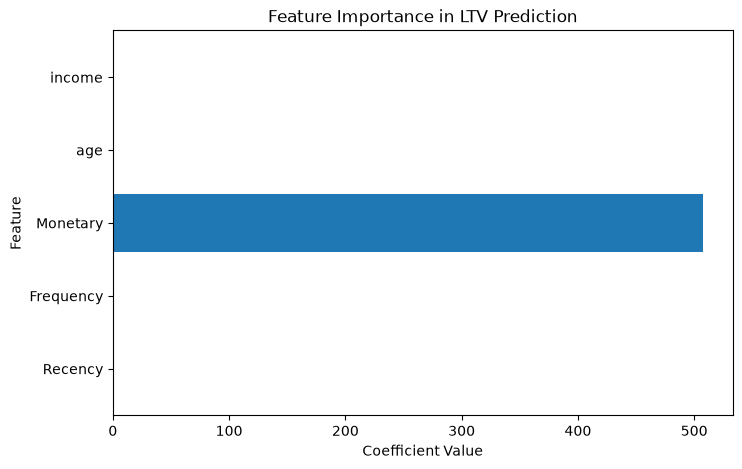

In [55]:
plt.figure(figsize=(8,5))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.title("Feature Importance in LTV Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

The regression model identifies which customer features contribute most strongly toward predicted lifetime value. Higher positive coefficients indicate stronger contribution to customer value.

In [56]:
abt.to_csv("../data/processed/abt.csv", index=False)

## Statistical Validation using ANOVA

This section tests whether the spending behavior across customer clusters is statistically different.

In [57]:
cluster_groups = []

for cluster in abt["Cluster"].unique():
    group = abt[abt["Cluster"] == cluster]["Monetary"]
    cluster_groups.append(group)

In [58]:
f_statistic, p_value = f_oneway(*cluster_groups)

print("F-statistic:", f_statistic)
print("P-value:", p_value)

F-statistic: 189.46642204140036
P-value: 7.454070371279469e-82


The ANOVA test shows a statistically significant difference in monetary spending across the customer clusters because the p-value is less than 0.05. This confirms that the identified segments represent meaningful behavioral differences.

The ANOVA test does not show strong statistical evidence of differences between the customer segments, but the clustering still provides practical business insights.

In [59]:
abt.groupby("Cluster")["Monetary"].mean()

Cluster
0    1776.610847
1     860.129483
2     935.437355
3    1040.638232
Name: Monetary, dtype: float64

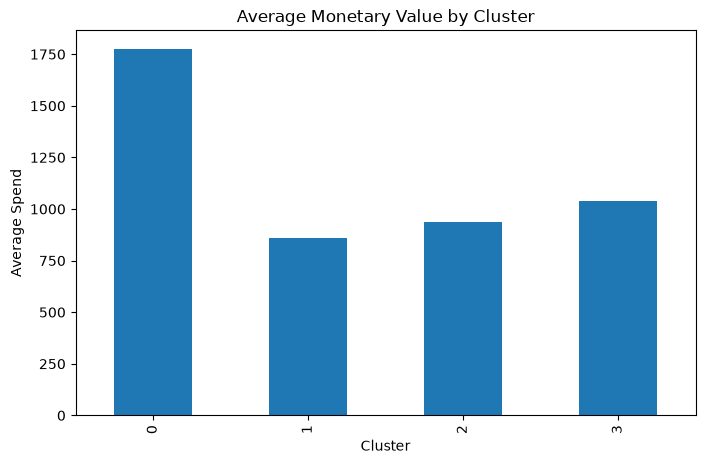

In [60]:
plt.figure(figsize=(8,5))
abt.groupby("Cluster")["Monetary"].mean().plot(kind="bar")
plt.title("Average Monetary Value by Cluster")
plt.ylabel("Average Spend")
plt.show()